In [37]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
#load the banglore dataset
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


Exploratory Data Analysis

In [39]:
#Drop unwanted columns
cols = ["area_type","availability","society","balcony"]
df = df.drop(cols,axis=1)
df.head()


,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [41]:
#Drop duplicate rows
df.drop_duplicates(inplace=True)

In [42]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          72
price          0
dtype: int64

In [43]:
#cleaning Location column

#i) Remove leading and trailing spaces
df["location"] = df["location"].str.strip()

#ii) handling nan values in location with top 2nd location--> Sarjapur  Road
df["location"]=df["location"].fillna("Sarjapur  Road")

#iii) Grouping the locations with less than 10 houses into others category
loc = df["location"].value_counts()
loc_less_than_10 = loc[loc<=10]
df["location"] = df["location"].apply(lambda x: "others" if x in loc_less_than_10 else x)

In [44]:
#cleaning size column

#i)handling nan values in size column
df["size"] = df["size"].fillna("2 BHK")

#ii)extract only the bhk number and remove unwanted chars
df["size"] = df["size"].apply(lambda x: int(x.split()[0]))
df["size"].unique()

#iii)renaming size to bhk
df.rename(columns={"size":"bhk"},inplace=True)

In [45]:
#clean total_sqft column
def clean_total_sqft(sqft):
    try:
        l = sqft.split("-")
        if len(l)==2:
            return (float(l[0])+float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None
    
df["total_sqft"] = df["total_sqft"].apply(clean_total_sqft)

#handling nan values in total_sqft
df["total_sqft"] = df["total_sqft"].fillna(round(df["total_sqft"].mean()))

In [46]:
#handling nan values in bath
med = df["bath"].median()
df["bath"] = df["bath"].fillna(med)
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

Handling Outliers

In [47]:
#create a new col price_per_sqft
#formula:  price_per_sqft = price/total_sqft
df["price_per_sqft"] = (df["price"]*100000)/df["total_sqft"]

In [48]:
#handling outliers in total_sqft
#Observation:  In total_sqft column we have houses less than 300 sqft those are outliers
#In real-time houses starts with min of 300 sqft

#formula:  total_sqft/bhk>=300 ---> it keeps all the realistic total sqft

df = df[df["total_sqft"]/df["bhk"]>=300]
df.describe()

,bhk,total_sqft,bath,price,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,2.666809,1614.029039,2.579667,114.455648,6405.091922
std,0.995743,1296.481391,1.099383,156.421987,4281.960473
min,1.000000,300.000000,1.000000,8.440000,267.829813
25%,2.000000,1120.000000,2.000000,50.000000,4253.521127
50%,3.000000,1314.000000,2.000000,71.000000,5348.837209
75%,3.000000,1720.000000,3.000000,120.000000,7000.000000
max,16.000000,52272.000000,16.000000,3600.000000,176470.588235


All unrealistic rows with total_sqft less than 300 got removed

<Axes: xlabel='bhk'>

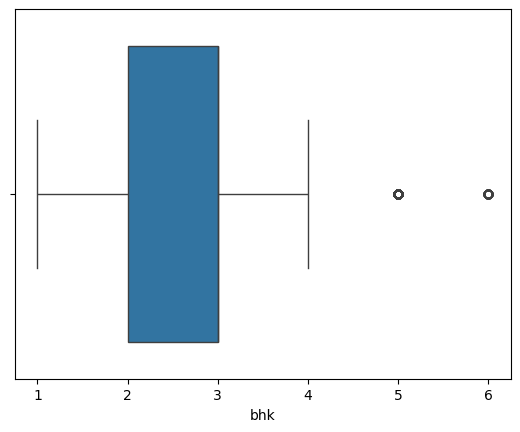

In [49]:
#Handling outliers in bhk
df["bhk"].unique()
df = df[df["bhk"]<=6]
sns.boxplot(x="bhk",data=df)

In [50]:
#Handling outliers in bath column
# Observation: Here no.of.bath count is suspeciously high compared to bhk number these are outliers
df[df["bath"]>df["bhk"]+2][["bhk","bath"]]
df = df[df["bath"]<df["bhk"]+2] #-->It removes unrealistic values where no.of.bath count is suspeciously high compared to bhk

<Axes: xlabel='price_per_sqft'>

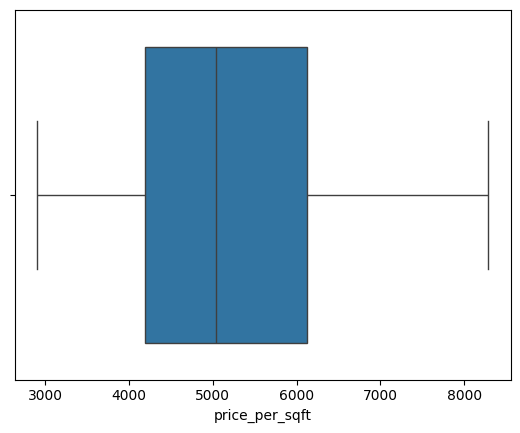

In [51]:
#Handling outliers in price_per_sqft
#IQR Method
q1 = df["price_per_sqft"].quantile(0.25)
q3 = df["price_per_sqft"].quantile(0.75)
IQR = q3-q1
lower = q1-0.5*IQR
upper = q3+0.5*IQR
df = df[(df["price_per_sqft"]>=lower) & (df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)

In [52]:
#remove price_per_sqft
df = df.drop("price_per_sqft",axis=1)

In [53]:
#reset the index
df.reset_index(inplace=True)
df = df.drop("index",axis=1)
df.head()

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00


In [54]:
df

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71
9357,Bellandur,2,1262.0,2.0,47.00
9358,Green Glen Layout,3,1715.0,3.0,112.00
9359,Whitefield,5,3453.0,4.0,231.00


Text(0.5, 1.0, 'Total sqft vs Price')

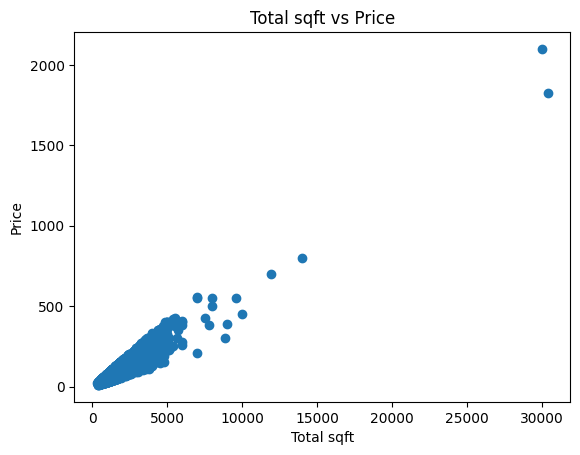

In [55]:
plt.scatter(df["total_sqft"],df["price"])
plt.xlabel("Total sqft")
plt.ylabel("Price")
plt.title("Total sqft vs Price")

<Axes: >

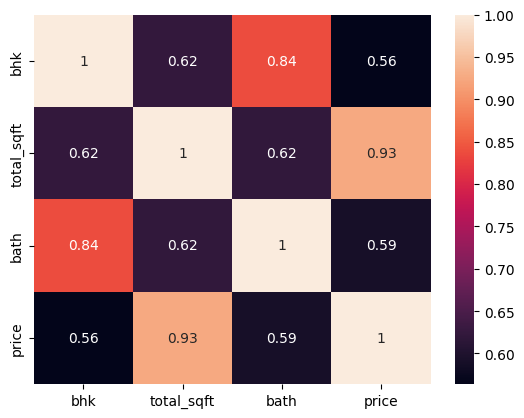

In [56]:
corr_data = df.iloc[:,1:].corr()
sns.heatmap(corr_data,annot=True)

In [57]:
#Avg price by location
data = df.groupby("location")["price"].mean().sort_values()
data

location
Kereguddadahalli         34.678571
Dommasandra              37.837500
Bisuvanahalli            40.805000
Anekal                   41.216000
Giri Nagar               42.000000
                           ...    
Hebbal Kempapura        154.363636
Doddaballapur           157.375000
Sector 7 HSR Layout     195.500000
2nd Stage Nagarbhavi    205.000000
Iblur Village           227.250000
Name: price, Length: 231, dtype: float64

Model Training & Evaluation

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [59]:
#Encoding Location column
encoder = LabelEncoder()
df["encoded_loc"] = encoder.fit_transform(df["location"])

In [60]:
#Divide data into input and output features
X = df.drop(["location","price"],axis=1)
y = df.price

In [61]:
#split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

Linear Regression

In [62]:
#model training
LR = LinearRegression()
LR.fit(Xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
ypred = LR.predict(Xtest)
ypred

array([82.02250319, 62.36595282, 78.92817568, ..., 67.21954379,
       63.22784938, 66.58757742])

In [64]:
print("Training Eff: ",LR.score(Xtrain,ytrain))
print("Testing Eff: ",LR.score(Xtest,ytest))
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.8729434702335231
Testing Eff:  0.8119143581760945
R2:  0.8119143581760945
MAE:  14.79587726948248


Decision Tree

In [65]:
DT = DecisionTreeRegressor()
DT.fit(Xtrain,ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [66]:
ypred = DT.predict(Xtest)
ypred

array([120.  ,  44.  ,  68.  , ...,  58.17,  50.  ,  95.  ])

In [67]:
print("Training Eff: ",DT.score(Xtrain,ytrain))
print("Testing Eff: ",DT.score(Xtest,ytest))
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.991086473248075
Testing Eff:  0.7175776973042234
R2:  0.7175776973042234
MAE:  15.724101958362578


Decision Tree is Overfitting cause the data is linear 
Here Linear Regresison model is the best performing model

In [68]:
#using pickle
#Model serialization-->Saving the trained model
#req:  it skips the continuous training process
import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(LR,file)

In [69]:
#encoder serialization
with open("label_encoder.pkl","wb") as file:
    pickle.dump(encoder,file)

In [70]:
#save the cleaned data
df.to_csv("cleaned_data.csv")